# 🎬 Netflix Movies & TV Shows Data Analysis

## Objective

This project explores Netflix's catalog using Python, Pandas, NumPy, and Matplotlib to uncover trends in content type, ratings, countries, genres, and release years.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [56]:
df.shape

(8807, 12)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [58]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Data Cleaning

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [61]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

# Question 1: What is the Distribution of Movies and TV Shows on Netflix?

## Why?

Understanding the proportion of Movies and TV Shows provides a high-level overview of Netflix's content library and helps identify the platform's primary focus.

## Hypothesis

I expect Movies to significantly outnumber TV Shows because producing movies generally requires less long-term commitment than creating television series.

## Approach

- Count each content type.
- Visualize the distribution using a bar chart.
- Compare the number of Movies and TV Shows.

In [62]:
df["date_added"].isna().sum()

np.int64(10)

In [63]:
type_counts = df["type"].value_counts()
type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

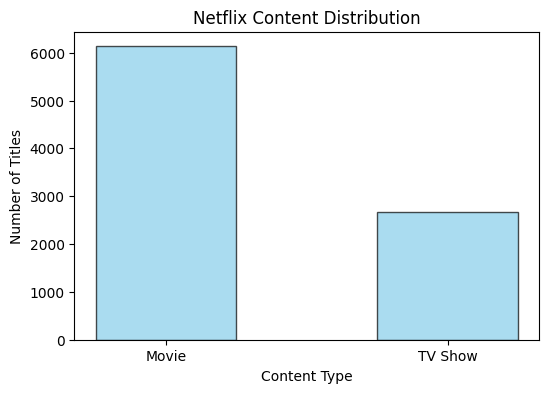

In [64]:
plt.figure(figsize=(6,4))

plt.bar(type_counts.index, type_counts.values, color='skyblue' ,edgecolor='black', alpha=0.7 , width=0.5, align='center')

plt.title("Netflix Content Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.savefig("../images/movies_vs_tvshows.png", dpi=300, bbox_inches="tight")
plt.show()

## Insights

- Movies make up a significantly larger portion of Netflix's catalog than TV Shows.
- The number of Movies is more than twice the number of TV Shows, indicating that Netflix places greater emphasis on film content.
- Although TV Shows represent a smaller share of the catalog, they still account for a substantial portion of Netflix's overall library.

# Question 2: Which Countries Contribute the Most Content to Netflix?

## Why?

Netflix operates globally. Identifying the countries contributing the largest number of titles helps understand regional production trends and Netflix's international presence.

## Hypothesis

I expect the United States and India to be among the top contributors because they produce a large volume of films and television content every year.

## Approach

- Ignore missing values.
- Split rows containing multiple countries.
- Remove unnecessary spaces.
- Count every country individually using a dictionary.
- Sort the countries by frequency.
- Visualize the top contributors.

In [65]:
df["country"].head(10)

0                                        United States
1                                         South Africa
2                                                  NaN
3                                                  NaN
4                                                India
5                                                  NaN
6                                                  NaN
7    United States, Ghana, Burkina Faso, United Kin...
8                                       United Kingdom
9                                        United States
Name: country, dtype: object

In [66]:
df["country"].value_counts()

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [67]:
country = "United States, India"

countries = country.split(",")

print(countries)

['United States', ' India']


In [68]:
for c in countries:
    print(c)

United States
 India


In [69]:
country_counts = {}
for countries in df["country"]:
    print(countries)

United States
South Africa
nan
nan
India
nan
nan
United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia
United Kingdom
United States
nan
nan
Germany, Czech Republic
nan
nan
United States
nan
Mexico
nan
nan
nan
Turkey
nan
nan
India
Australia
nan
United States
United States
United States, India, France
nan
nan
United Kingdom
nan
nan
nan
nan
Finland
China, Canada, United States
India
United States
United States
United States
United States
United States
nan
South Africa, United States, Japan
nan
United States
Nigeria
India
Japan
Japan
Japan
Japan
United States
Japan
Japan
Japan
Japan
Japan
Japan
Japan
Japan
nan
United Kingdom
India
United States
nan
India
nan
nan
United Kingdom
Nigeria
nan
nan
Japan
nan
nan
nan
nan
United States
United States
nan
Nigeria
nan
nan
nan
nan
nan
Spain, United States
France
Belgium
nan
United Kingdom, United States
United States, United Kingdom
United States
United States
United Kingdom
France, United States
nan
United States
nan
nan
South Korea
I

In [70]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [71]:
country_counts = {}

for countries in df["country"]:

    if pd.isna(countries):
        continue

    countries = countries.split(",")

    for country in countries:

        country = country.strip()

        if country in country_counts:
            country_counts[country] += 1
        else:
            country_counts[country] = 1
print(country_counts)

{'United States': 3690, 'South Africa': 62, 'India': 1046, 'Ghana': 5, 'Burkina Faso': 1, 'United Kingdom': 806, 'Germany': 226, 'Ethiopia': 1, 'Czech Republic': 22, 'Mexico': 169, 'Turkey': 113, 'Australia': 160, 'France': 393, 'Finland': 11, 'China': 162, 'Canada': 445, 'Japan': 318, 'Nigeria': 103, 'Spain': 232, 'Belgium': 90, 'South Korea': 231, 'Singapore': 41, 'Italy': 100, 'Romania': 14, 'Argentina': 91, 'Venezuela': 4, 'Hong Kong': 105, 'Russia': 27, '': 7, 'Ireland': 46, 'Nepal': 2, 'New Zealand': 33, 'Brazil': 97, 'Greece': 11, 'Jordan': 9, 'Colombia': 52, 'Switzerland': 19, 'Israel': 30, 'Taiwan': 89, 'Bulgaria': 10, 'Algeria': 3, 'Poland': 41, 'Saudi Arabia': 13, 'Thailand': 70, 'Indonesia': 90, 'Egypt': 117, 'Denmark': 48, 'Kuwait': 8, 'Netherlands': 50, 'Malaysia': 26, 'Vietnam': 7, 'Hungary': 11, 'Sweden': 42, 'Lebanon': 31, 'Syria': 3, 'Philippines': 83, 'Iceland': 11, 'United Arab Emirates': 37, 'Norway': 30, 'Qatar': 10, 'Mauritius': 2, 'Austria': 12, 'Cameroon': 1, '

In [72]:
sorted_countries = sorted(
    country_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

In [73]:
top_10 = sorted_countries[:10]
countries = [item[0] for item in top_10]
counts = [item[1] for item in top_10]

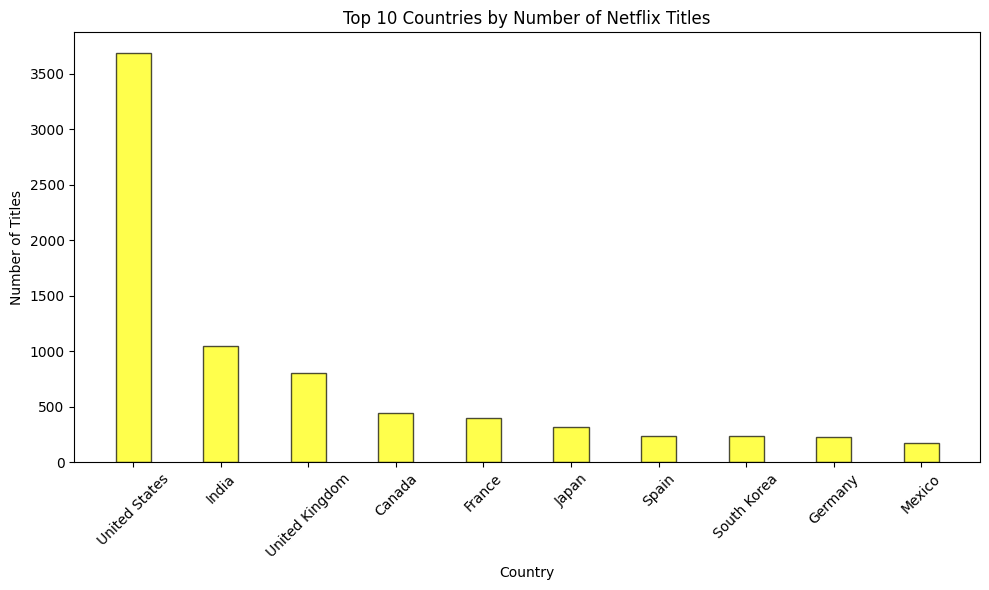

In [74]:
plt.figure(figsize=(10, 6))
plt.bar(countries, counts, color='yellow', edgecolor='black', alpha=0.7, width=0.4, align='center')
plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/top_countries.png", dpi=300, bbox_inches="tight")
plt.show()

### Insights

- The United States contributes the largest number of titles to Netflix.
- India ranks among the top contributors, reflecting its large film industry.
- Content production is concentrated in a relatively small number of countries.

# Question 3: How Has Netflix's Library Grown Over Time?

## Why?

Analyzing the number of titles added each year helps understand Netflix's expansion strategy and periods of rapid growth.

## Hypothesis

I expect the number of titles added to increase steadily until around 2019, after which the growth may stabilize or decline.

## Approach

- Convert the date column into datetime format.
- Extract the year from the date.
- Count titles added each year.
- Visualize the trend using a line chart.

In [75]:
df["date_added"].dtype

dtype('O')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [77]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="mixed",
    errors="coerce"
)

In [78]:
df["year_added"] = df["date_added"].dt.year

In [79]:
year_counts = df["year_added"].value_counts().sort_index()

year_counts

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

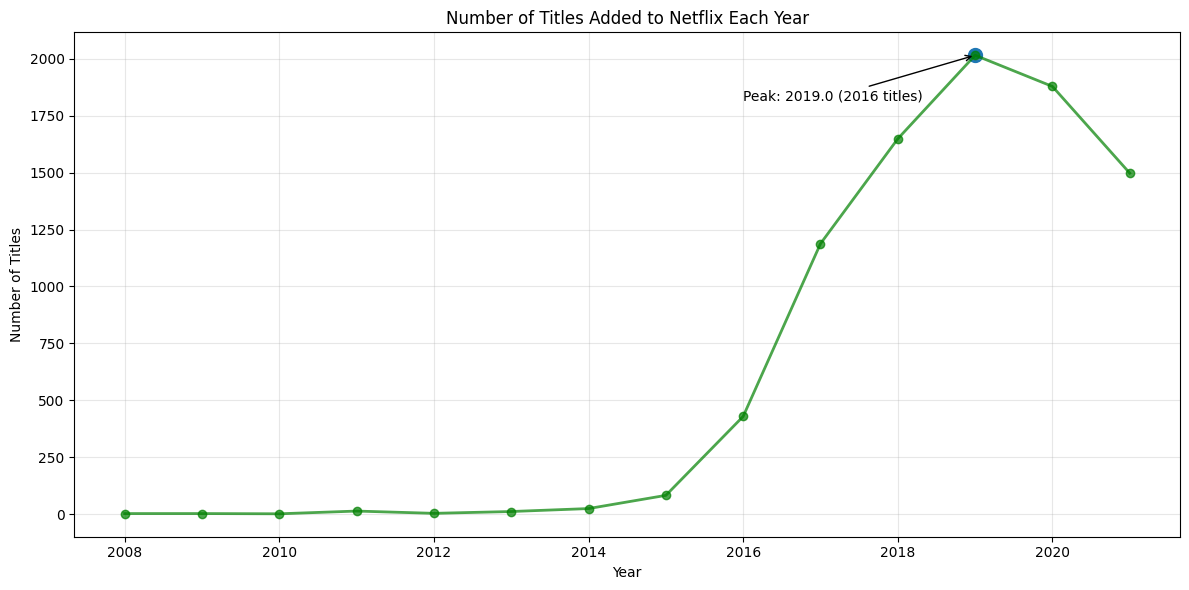

In [80]:
year_counts = df["year_added"].value_counts().sort_index()
peak_year = year_counts.idxmax()
peak_titles = year_counts.max()

plt.figure(figsize=(12,6))
plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    linewidth=2,
    alpha=0.7,
    color="green",
    linestyle="-"
)
plt.scatter(peak_year, peak_titles, s=100)
plt.annotate(
    f"Peak: {peak_year} ({peak_titles} titles)",
    xy=(peak_year, peak_titles),
    xytext=(peak_year-3, peak_titles-200),
    arrowprops=dict(arrowstyle="->")
)
plt.title("Number of Titles Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../images/titles_added.png", dpi=300, bbox_inches="tight")
plt.show()

## Insights

- Netflix added relatively few titles before 2015, suggesting a smaller content library during its early years.
- The number of titles added increased rapidly between 2016 and 2019, reflecting Netflix's aggressive expansion of its catalog.
- The highest number of titles was added in **2019**, making it the peak year in the dataset.
- The decline after 2019 may be influenced by incomplete data for more recent years rather than a true reduction in Netflix's content acquisition.

# Question 4: What are the Most Common Netflix Content Ratings?

## Why?

Content ratings help understand the target audience and maturity level of Netflix's catalog.

## Hypothesis

I expect TV-MA and TV-14 to dominate because Netflix produces a large amount of content aimed at teenagers and adults.

## Approach

- Count each rating.
- Sort ratings by frequency.
- Display the results using a bar chart.


In [81]:
rating_counts = df["rating"].value_counts()
rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

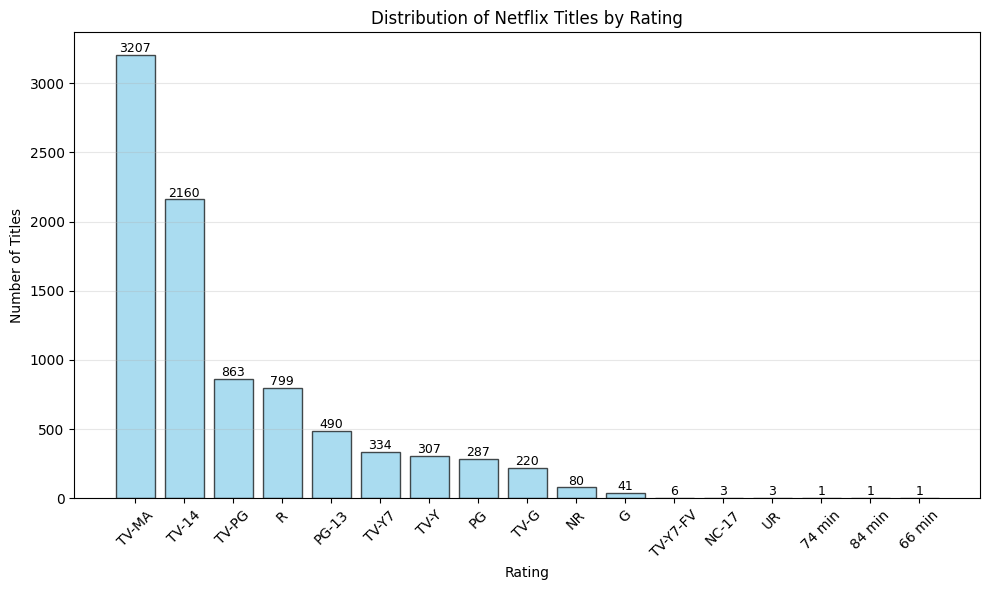

In [82]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    rating_counts.index,
    rating_counts.values,
    color="skyblue",
    edgecolor="black",
    alpha=0.7
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        int(bar.get_height()),
        ha="center",
        fontsize=9
    )
plt.title("Distribution of Netflix Titles by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", alpha=0.3)
plt.savefig("../images/rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Insights

- TV-MA is the most common rating, indicating a strong focus on mature audiences.
- TV-14 also represents a significant portion of the catalog.
- Family-friendly ratings such as G and TV-Y are comparatively less common.

## Question 5: What are the Most Popular Genres on Netflix?

### Why?

Genres reveal the type of content Netflix offers and help identify audience preferences. Understanding the most common genres provides insight into Netflix's content strategy and production focus.

### Hypothesis

I expect **Dramas**, **International Movies**, and **Comedies** to be among the most common genres, as they appeal to a broad global audience.

### Approach

- Ignore missing values.
- Split rows containing multiple genres.
- Remove unnecessary spaces.
- Count each genre individually.
- Sort the genres by frequency.
- Visualize the top 10 genres using a bar chart.

In [83]:
genre_counts = {}

for genres in df["listed_in"]:

    if pd.isna(genres):
        continue

    genres = genres.split(",")

    for genre in genres:

        genre = genre.strip()

        if genre in genre_counts:
            genre_counts[genre] += 1
        else:
            genre_counts[genre] = 1

In [84]:
sorted_genres = sorted(
    genre_counts.items(),
    key=lambda x: x[1],
    reverse=True
)
sorted_genres

[('International Movies', 2752),
 ('Dramas', 2427),
 ('Comedies', 1674),
 ('International TV Shows', 1351),
 ('Documentaries', 869),
 ('Action & Adventure', 859),
 ('TV Dramas', 763),
 ('Independent Movies', 756),
 ('Children & Family Movies', 641),
 ('Romantic Movies', 616),
 ('TV Comedies', 581),
 ('Thrillers', 577),
 ('Crime TV Shows', 470),
 ("Kids' TV", 451),
 ('Docuseries', 395),
 ('Music & Musicals', 375),
 ('Romantic TV Shows', 370),
 ('Horror Movies', 357),
 ('Stand-Up Comedy', 343),
 ('Reality TV', 255),
 ('British TV Shows', 253),
 ('Sci-Fi & Fantasy', 243),
 ('Sports Movies', 219),
 ('Anime Series', 176),
 ('Spanish-Language TV Shows', 174),
 ('TV Action & Adventure', 168),
 ('Korean TV Shows', 151),
 ('Classic Movies', 116),
 ('LGBTQ Movies', 102),
 ('TV Mysteries', 98),
 ('Science & Nature TV', 92),
 ('TV Sci-Fi & Fantasy', 84),
 ('TV Horror', 75),
 ('Anime Features', 71),
 ('Cult Movies', 71),
 ('Teen TV Shows', 69),
 ('Faith & Spirituality', 65),
 ('TV Thrillers', 57),


In [85]:
genre_counts = (
    df["listed_in"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

top_10 = genre_counts.head(10)

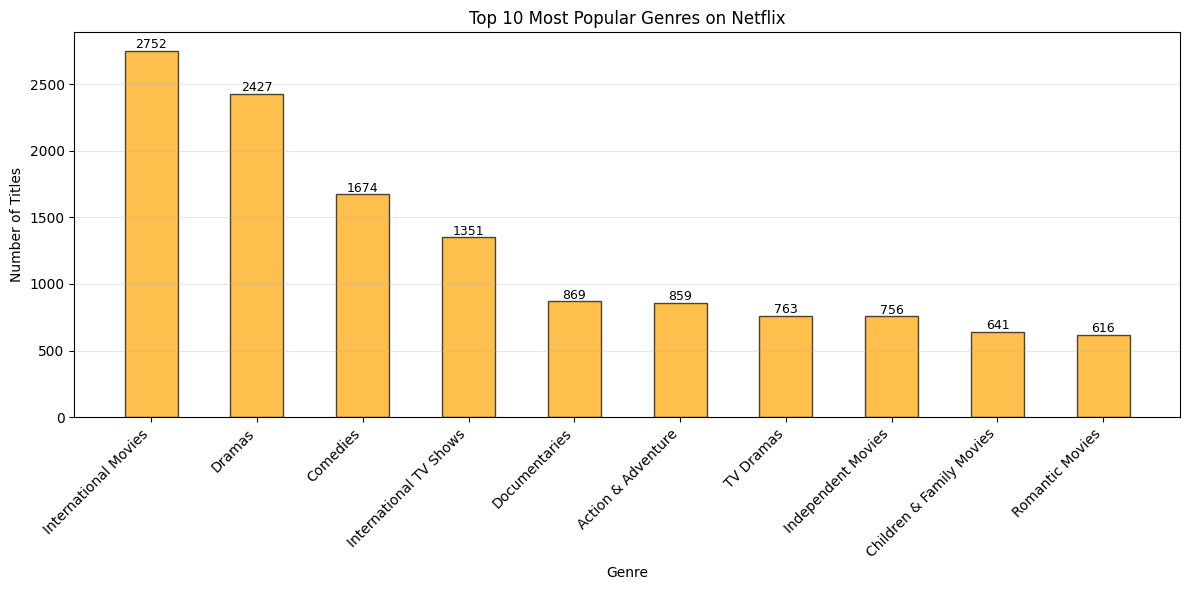

In [86]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_10.index,
    top_10.values,
    color="orange",
    edgecolor="black",
    alpha=0.7, width=0.5, align="center"
)
plt.title("Top 10 Most Popular Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        int(bar.get_height()),
        ha="center",
        fontsize=9
    )
plt.tight_layout()
plt.savefig("../images/top_genres.png", dpi=300, bbox_inches="tight")
plt.show()

### Insights

- The top few genres account for a significant portion of Netflix's catalog.
- Drama-related genres dominate the platform, indicating a strong focus on story-driven content.
- International genres appear frequently, reflecting Netflix's investment in global content.
- Since many titles belong to multiple genres, each genre was counted individually during preprocessing.

# Question 6: Which Directors Have the Most Titles on Netflix?

## Why?

Identifying frequently appearing directors provides insight into creators who have contributed extensively to Netflix's catalog.

## Hypothesis

I expect a small number of directors to appear repeatedly, while most directors contribute only a few titles.

## Approach

- Ignore missing values.
- Split rows containing multiple directors if present.
- Remove unnecessary spaces.
- Count the number of titles directed by each director.
- Display the top 10 directors.

In [87]:
director_counts = {}

for directors in df["director"]:

    if pd.isna(directors):
        continue

    directors = directors.split(",")

    for director in directors:

        director = director.strip()

        if director in director_counts:
            director_counts[director] += 1
        else:
            director_counts[director] = 1

sorted_directors = sorted(
    director_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

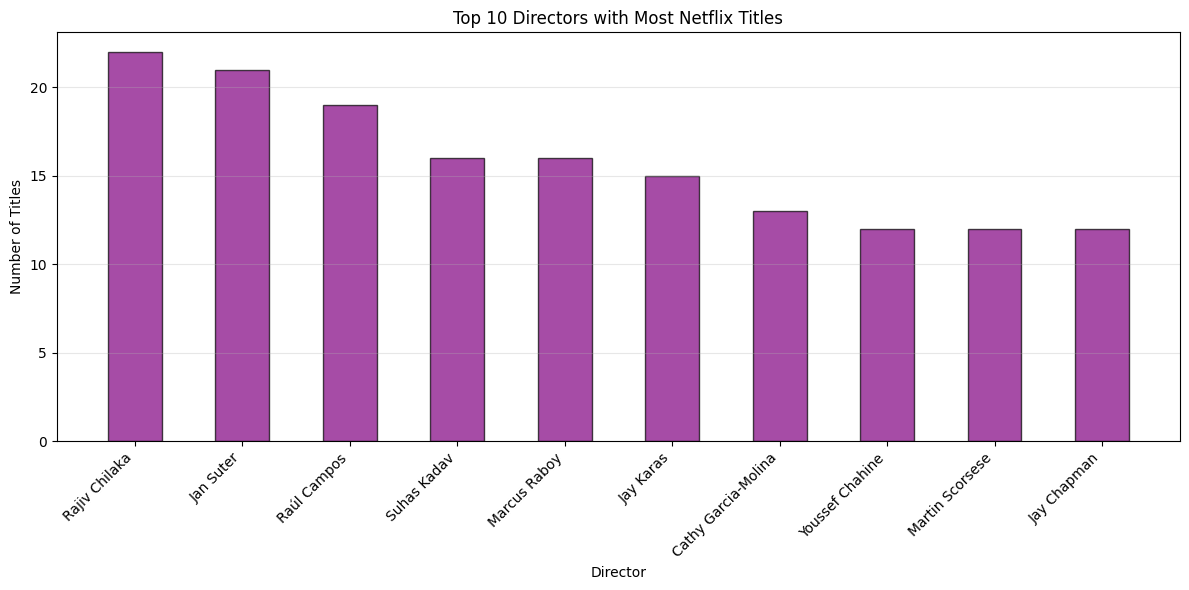

In [88]:
top_10 = sorted_directors[:10]
directors = [item[0] for item in top_10]
counts = [item[1] for item in top_10]
plt.figure(figsize=(12,6))
bars = plt.bar(
    directors,
    counts,
    color="purple",
    edgecolor="black",
    alpha=0.7, width=0.5, align="center"
)
plt.title("Top 10 Directors with Most Netflix Titles")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right") 
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../images/top_directors.png", dpi=300, bbox_inches="tight")
plt.show()

## Insights

- Rajiv Chilaka has the highest number of titles in the dataset, making him the most frequently appearing director on Netflix.
- The difference between the top-ranked directors is relatively small, suggesting that Netflix's catalog is distributed across a wide range of filmmakers rather than being dominated by a single director.
- Several directors have contributed between 12 and 22 titles, indicating a diverse mix of recurring creators.
- The presence of directors from different countries highlights Netflix's investment in international productions and global storytelling.

# Question 7: What is the Distribution of Movie Durations?

## Why?

Movie duration provides insight into the typical length of films available on Netflix.

## Hypothesis

I expect most movies to fall between 80 and 120 minutes.

## Approach

- Filter the dataset to include Movies only.
- Remove the "min" text from the duration column.
- Convert the duration to integers.
- Visualize the distribution using a histogram.

In [89]:
movies = df[df["type"] == "Movie"].copy()

# Remove movies with missing duration
movies = movies.dropna(subset=["duration"])

# Remove " min" and convert to integer
movies["duration"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False)
    .astype(int)
)

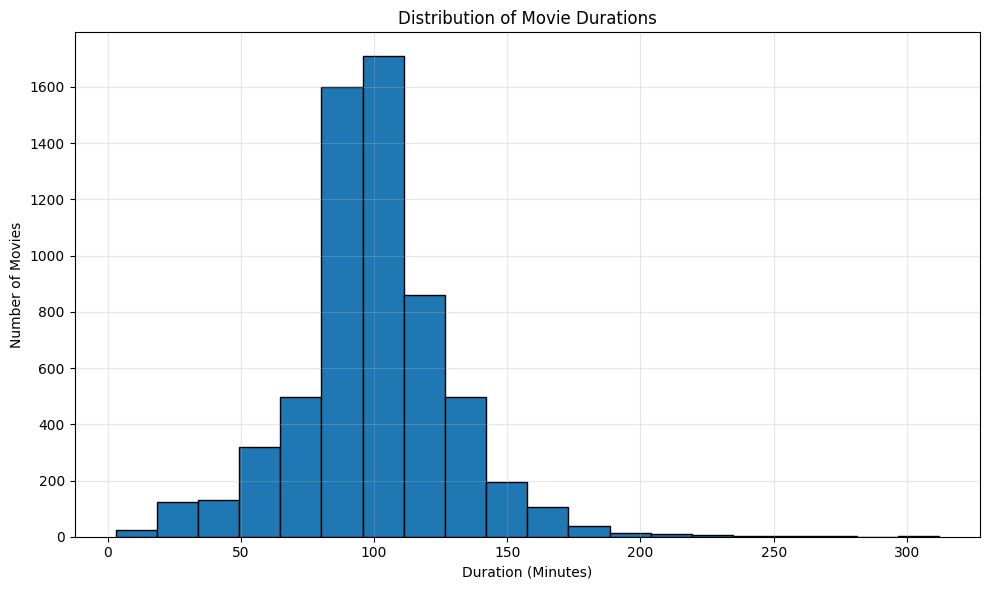

In [90]:
plt.figure(figsize=(10,6))
plt.hist(
    movies["duration"],
    bins=20,
    edgecolor="black"
)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../images/movie_durations.png", dpi=300, bbox_inches="tight")
plt.show()

## Insights

- Most movies on Netflix have durations between **80 and 120 minutes**, indicating that feature-length films dominate the platform.
- There are a few unusually long movies, but they are relatively uncommon.
- Very short movies (less than 60 minutes) are rare compared to standard-length feature films.
- Movies longer than **180 minutes** are uncommon, suggesting Netflix's catalog primarily consists of conventionally timed films.
- The peak of the distribution lies around **90–110 minutes**, which appears to be the typical movie duration on Netflix.

# Question 8: How Has Content Production Changed Over the Years?

## Why?

Examining release years helps understand how Netflix's catalog is distributed across different production periods.

## Hypothesis

I expect most titles to have been released during the last decade.

## Approach

- Count titles released each year.
- Sort the years chronologically.
- Plot the trend using a line chart.

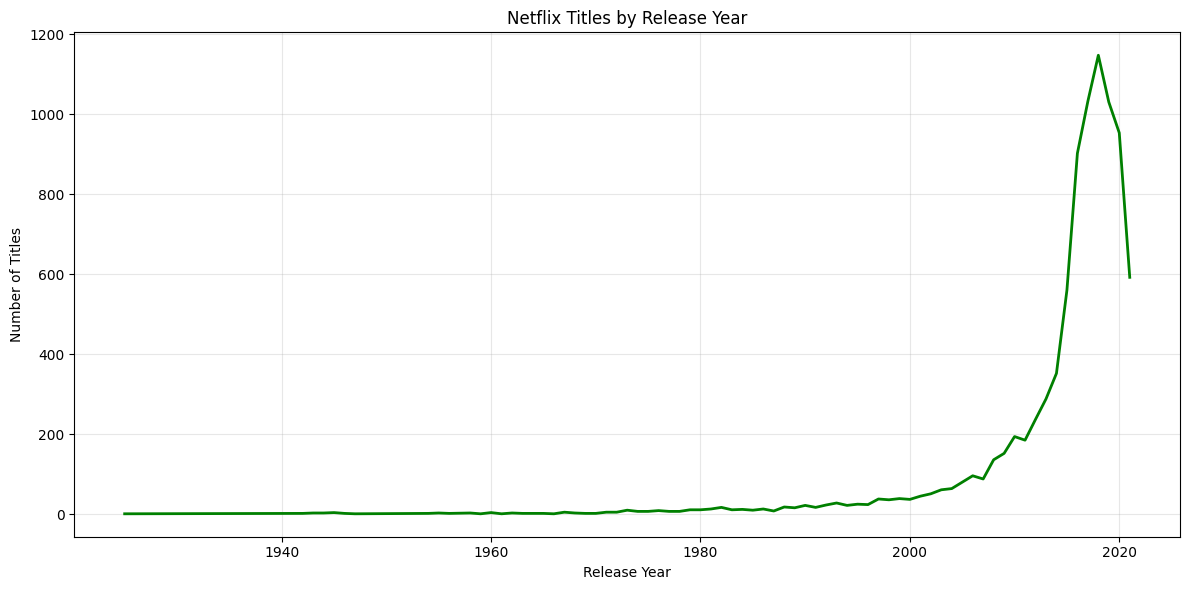

In [91]:
release_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(
    release_counts.index,
    release_counts.values,
    color="green",
    linewidth=2, linestyle="-"
)
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../images/release_years.png", dpi=300, bbox_inches="tight")
plt.show()

## Insights

- The number of Netflix titles released each year remained relatively low until the early 2000s.
- Content production increased steadily after 2000 and accelerated significantly during the 2010s.
- The highest number of titles in the dataset were released around **2018**, indicating Netflix's strongest period of content acquisition and production.
- After the peak, the number of released titles declines for more recent years. This is likely because newer years contain incomplete data rather than a true decrease in production.
- The overall trend suggests that Netflix's catalog is heavily concentrated in modern content, with comparatively few titles released before the 1990s.

# Final Conclusion

## Key Findings

- Movies make up a larger portion of Netflix's catalog than TV Shows.
- The United States and India contribute the highest number of titles.
- Netflix experienced rapid growth in content additions during the late 2010s.
- Mature audience ratings such as TV-MA dominate the catalog.
- Drama and International genres are among the most common genres.
- Most movies have durations between 80 and 120 minutes.
- The majority of titles were released within the last decade.

## Skills Demonstrated

Throughout this project, I applied:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Python Programming
- Pandas
- NumPy
- Matplotlib
- Dictionary-based counting algorithms
- Data Visualization
- Data Interpretation

# Future Improvements

- Perform sentiment analysis using title descriptions.
- Build a recommendation system based on genres and descriptions.
- Create an interactive dashboard using Plotly or Streamlit.
- Analyze actor collaborations and country co-productions.
- Compare Netflix's catalog growth across different regions.